In [1]:
# import labraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# dataset load libraried
from datasets import load_dataset

### Data set :- https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset =load_dataset('dair-ai/emotion')


train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names

df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'LABEL' : test_label
    }
)

In [4]:
df_train.isnull().sum()

,0
text,0
label,0


In [5]:
df_test.isnull().sum()

,0
text,0
LABEL,0


### *EDA*

In [6]:
order = df_train['label'].value_counts().index
order

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

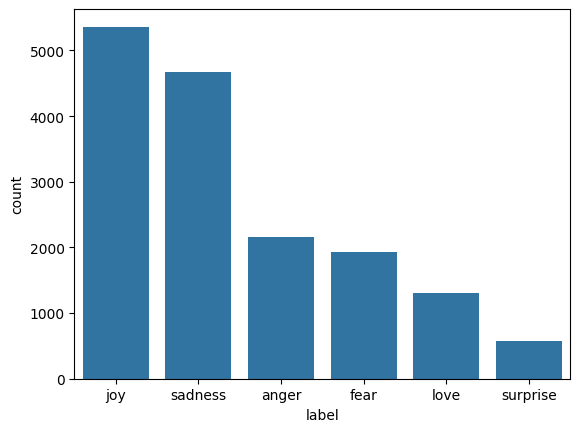

In [7]:
sns.countplot(x= 'label', data = df_train, order= order)

In [8]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## Data Preprocessing NLP

In [9]:
# Tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words= max_words, oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])


padded_train_sequence = pad_sequences(train_sequence, maxlen =50, padding ='post', truncating='post')
padded_test_sequences = pad_sequences (test_sequence, maxlen =50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)


num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max Sentences Length :{padded_train_sequence.shape[1]}")


Vocabulary size: 15213
Max Sentences Length :50


## Training Utilities

In [10]:
from sklearn.utils import class_weight


class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels

)

class_weight_dict = dict(enumerate(class_weights))

In [11]:
from seaborn.rcmod import reset_defaults
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

## Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units=128, return_sequences= True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5), # Hidden layers
    Dense(units= num_classes, activation = 'softmax') # output layer
])

rnn_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

# loss = actual and predictions difference



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequences, test_labels),
    epochs = 20,
    batch_size = 32,
    #validation_split = 0.2, # It is split a data from a test data 20 %
    class_weight = class_weight_dict,
    callbacks = [early_stopping]

)


rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)

print(f'RNN Loss :{rnn_loss}')
print(f'RNN Accuracy: {rnn_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.1610 - loss: 2.0394 - val_accuracy: 0.2490 - val_loss: 1.7716
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.1441 - loss: 1.8835 - val_accuracy: 0.0645 - val_loss: 1.8247
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.1349 - loss: 1.8298 - val_accuracy: 0.2690 - val_loss: 1.7555
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.1262 - loss: 1.8112 - val_accuracy: 0.1135 - val_loss: 1.7940
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.1291 - loss: 1.8048 - val_accuracy: 0.0840 - val_loss: 1.7818
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.1353 - loss: 1.8025 - val_accuracy: 0.0410 - val_loss: 1.8108
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2690 - loss: 1.7555
RNN Loss :1.7555094957351685
RNN Accuracy: 0.26899999380111694


In [14]:
## Model 2  = LSTM

lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units=128, return_sequences= True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5), # Hidden layers
    Dense(units= num_classes, activation = 'softmax') # output layer
])

lstm_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])



lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequences, test_labels),
    epochs = 20,
    batch_size = 32,
    #validation_split = 0.2, # It is split a data from a test data 20 %
    class_weight = class_weight_dict,
    callbacks = [early_stopping]

)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)

print(f'LSTM Loss :{lstm_loss}')
print(f'LSTM Accuracy: {lstm_accuracy}')




Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.1578 - loss: 1.7958 - val_accuracy: 0.2715 - val_loss: 1.7904
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.1626 - loss: 1.7936 - val_accuracy: 0.0940 - val_loss: 1.7797
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 145ms/step - accuracy: 0.1656 - loss: 1.7932 - val_accuracy: 0.0805 - val_loss: 1.7901
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.2715 - loss: 1.7904
LSTM Loss :1.7903660535812378
LSTM Accuracy: 0.27149999141693115


In [15]:
## Model 2  = GRU

gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units=128, return_sequences= True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5), # Hidden layers
    Dense(units= num_classes, activation = 'softmax') # output layer
])

gru_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])



gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequences, test_labels),
    epochs = 20,
    batch_size = 32,
    #validation_split = 0.2, # It is split a data from a test data 20 %
    class_weight = class_weight_dict,
    callbacks = [early_stopping]

)

gru_loss, gru_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)

print(f'GRU Loss :{gru_loss}')
print(f'GRU Accuracy: {gru_accuracy}')




Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 118ms/step - accuracy: 0.1583 - loss: 1.7972 - val_accuracy: 0.1135 - val_loss: 1.7733
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.1630 - loss: 1.7952 - val_accuracy: 0.1370 - val_loss: 1.8474
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.1591 - loss: 1.7946 - val_accuracy: 0.0330 - val_loss: 1.8109
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.2715 - loss: 1.7904
GRU Loss :1.7903660535812378
GRU Accuracy: 0.27149999141693115


In [16]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss ],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy ]
}).sort_values(by = 'Test Accuracy', ascending= False)



result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.790366,0.2715
2,GRU,1.790366,0.2715
0,RNN,1.755509,0.2690


In [17]:
## Advanced Bidirectional GRU

from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(128, return_sequences= True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5), # Hidden layers
    Dense(num_classes, activation = 'softmax')
])

BiGRU.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

BiGRU.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequences, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
    )

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 323ms/step - accuracy: 0.6029 - loss: 1.0033 - val_accuracy: 0.8825 - val_loss: 0.3912
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - accuracy: 0.9178 - loss: 0.2407 - val_accuracy: 0.9165 - val_loss: 0.2209
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 325ms/step - accuracy: 0.9435 - loss: 0.1513 - val_accuracy: 0.9220 - val_loss: 0.2179
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.9605 - loss: 0.1122 - val_accuracy: 0.9275 - val_loss: 0.2057
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 319ms/step - accuracy: 0.9676 - loss: 0.0925 - val_accuracy: 0.9160 - val_loss: 0.2301
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 316ms/step - accuracy: 0.9753 - loss: 0.0711 - val_accuracy: 0.9150 - val_loss: 0.2987
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 313ms/step - accuracy: 0.9813 - loss: 0.0552 - val_accuracy: 0.9250 - val_loss: 0.2760


In [19]:
BiGRU_loss, BiGRU_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)

print(f'BiGRU Loss :{BiGRU_loss}')
print(f'BiGRU Accuracy: {BiGRU_accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2715 - loss: 1.7904
BiGRU Loss :1.7903660535812378
BiGRU Accuracy: 0.27149999141693115


### Final Model

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step


<Axes: >

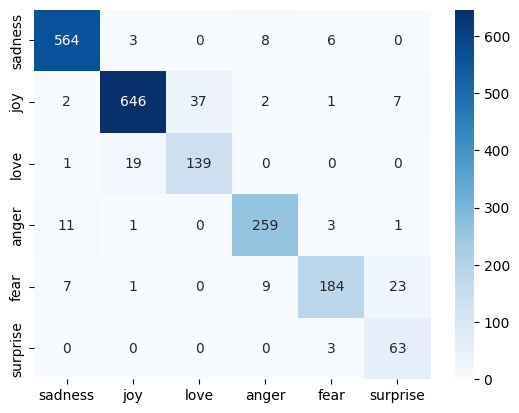

In [20]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences), axis =1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot = True, fmt = 'd', cmap = 'Blues', xticklabels= label_names, yticklabels = label_names)






### Final Predictions

In [21]:
from random import sample
sample_text = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"

]

sample_sequences = tokenizer.texts_to_sequences(sample_text)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen = 50, padding = 'post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis =1)
for i in range (len(sample_text)):
  print(f'Text: {sample_text[i]} \n Predicated Emotion : {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Text: I can't believe how happy I am right now, this is amazing! 
 Predicated Emotion : joy
Text: I feel so alone and hopeless today. 
 Predicated Emotion : sadness
Text: I am furious that they cancelled the trip at the last minute. 
 Predicated Emotion : anger
Text: I feel terrified when walking down dark alleyways alone. 
 Predicated Emotion : fear
Text: I was shocked and completely surprised by the unexpected gift! 
 Predicated Emotion : surprise


## Save Model & Tokenizer

In [22]:
import os
import pickle


model_dir = "Artifacts"# Folder Name
os.makedirs(model_dir, exist_ok= True)  # Folder Created



# Save BiGRU Model

BiGRU.save(os.path.join(model_dir, "biGRU_model.keras"))



# Save Tokenizer Model

with open (os.path.join(model_dir, 'tokenizer.pkl'), 'wb' ) as file:
  pickle.dump(tokenizer, file)